# Diagnóstico de Câncer de Mama com Machine Learning

Projeto avaliativo P2 - versão revisada da P1.

Disciplina: A.I - Machine Learning.

Integrantes:

- Rayssa Gomides Marconato - RA 2001130;
- Samara Adorno - RA 2001639.

Grupo: 5.

Tema: classificação de tumores mamários como benignos ou malignos usando características de exames citológicos.

Principais melhorias aplicadas após a devolutiva:

- separação estratificada em treino, validação e teste;
- tabela comparativa consolidada de métricas;
- EDA mais detalhada;
- seleção de features dentro do pipeline;
- salvamento do modelo final usado pelo app Streamlit.


## 1. Importação das bibliotecas

As bibliotecas abaixo cobrem manipulação de dados, visualização, divisão dos conjuntos, pipelines, padronização, seleção de features, treinamento dos modelos, avaliação e salvamento do modelo final.


In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

CURRENT = Path.cwd()
ROOT = CURRENT.parent if CURRENT.name == "notebooks" else CURRENT
DATA_PATH = ROOT / "data" / "dataset.csv"
MODEL_PATH = ROOT / "model" / "modelo_final.joblib"
FEATURES_PATH = ROOT / "model" / "feature_names.joblib"
REPORTS_PATH = ROOT / "reports"
REPORTS_PATH.mkdir(exist_ok=True)


## 2. Leitura e verificação dos dados

O dataset contém 569 amostras do Breast Cancer Wisconsin, com 30 variáveis numéricas extraídas de imagens de células mamárias. A variável-alvo é `diagnosis`, onde `M` representa maligno e `B` representa benigno.


In [2]:
df = pd.read_csv(DATA_PATH)
df.head()


,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,Unnamed: 32
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M,NaN
1,2,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M,NaN
2,3,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M,NaN
3,4,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M,NaN
4,5,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M,NaN


In [3]:
print("Dimensões:", df.shape)
df.info()


Dimensões: (569, 33)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   mean radius              569 non-null    float64
 2   mean texture             569 non-null    float64
 3   mean perimeter           569 non-null    float64
 4   mean area                569 non-null    float64
 5   mean smoothness          569 non-null    float64
 6   mean compactness         569 non-null    float64
 7   mean concavity           569 non-null    float64
 8   mean concave points      569 non-null    float64
 9   mean symmetry            569 non-null    float64
 10  mean fractal dimension   569 non-null    float64
 11  radius error             569 non-null    float64
 12  texture error            569 non-null    float64
 13  perimeter error          569 non-null    float64
 14  area error      

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()
print("Valores ausentes por coluna:")
print(missing[missing > 0])
print("Duplicatas:", duplicates)


Valores ausentes por coluna:
Unnamed: 32    569
dtype: int64
Duplicatas: 0


In [5]:
df.describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
id,569.0,285.000000,164.400426,1.00000,143.00000,285.00000,427.0000,569.0000
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.1957,0.3040


## 3. Análise exploratória dos dados

A EDA verifica o equilíbrio das classes, distribuição das variáveis, outliers e correlações. Isso ajuda a identificar padrões úteis para diferenciar tumores benignos e malignos.


,Quantidade,Percentual
diagnosis,,
B,357,62.74
M,212,37.26


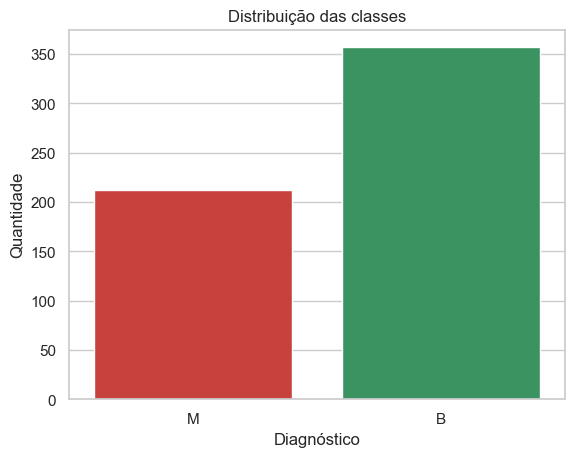

In [6]:
class_counts = df["diagnosis"].value_counts()
class_percent = df["diagnosis"].value_counts(normalize=True).mul(100).round(2)
class_table = pd.DataFrame({"Quantidade": class_counts, "Percentual": class_percent})
display(class_table)

sns.countplot(data=df, x="diagnosis", hue="diagnosis", palette={"B": "#2ca25f", "M": "#de2d26"}, legend=False)
plt.title("Distribuição das classes")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade")
plt.show()


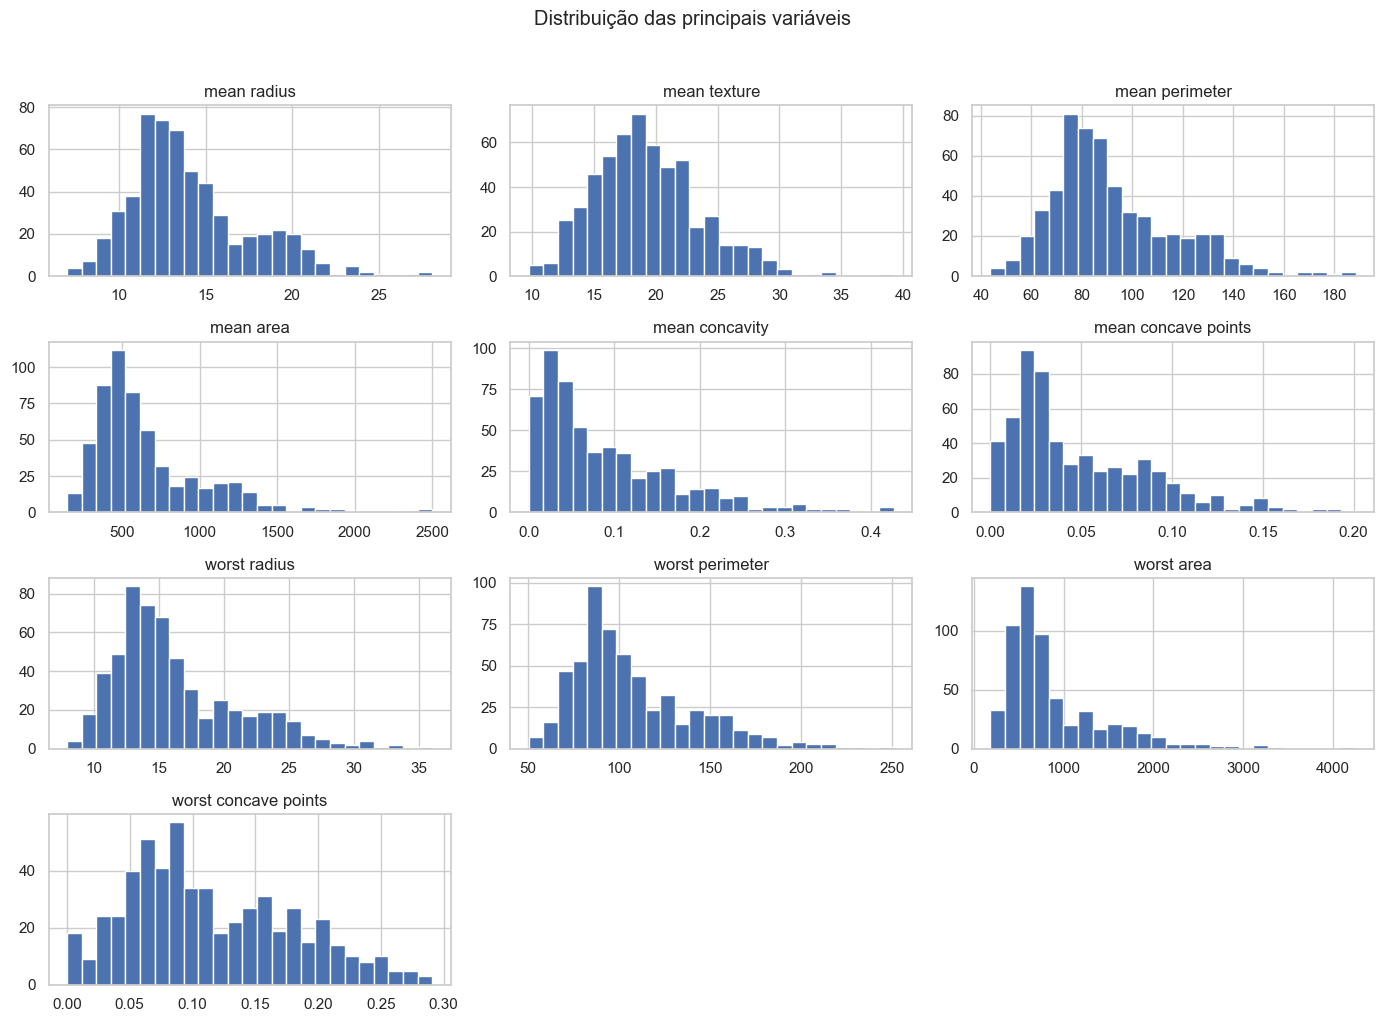

In [7]:
key_features = [
    "mean radius", "mean texture", "mean perimeter", "mean area",
    "mean concavity", "mean concave points", "worst radius", "worst perimeter",
    "worst area", "worst concave points"
]

df[key_features].hist(figsize=(14, 10), bins=25)
plt.suptitle("Distribuição das principais variáveis", y=1.02)
plt.tight_layout()
plt.show()


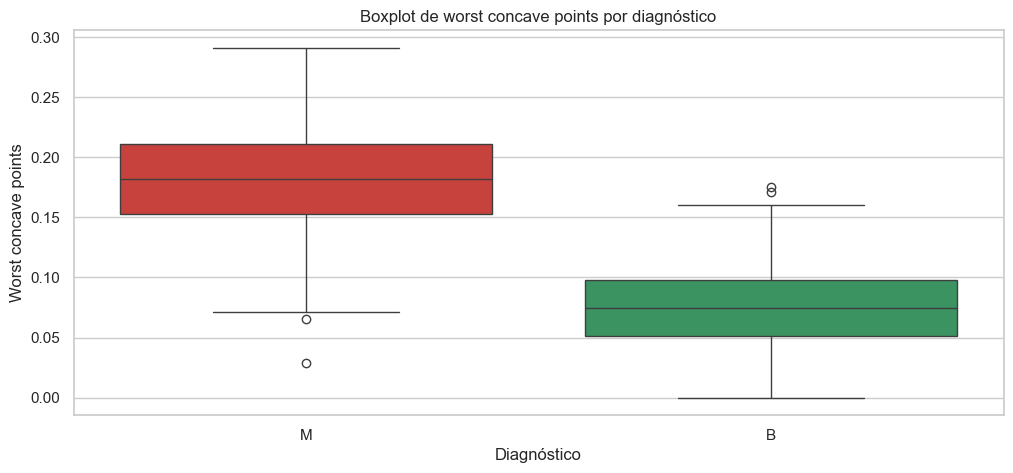

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="diagnosis", y="worst concave points", hue="diagnosis", palette={"B": "#2ca25f", "M": "#de2d26"}, legend=False)
plt.title("Boxplot de worst concave points por diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("Worst concave points")
plt.show()


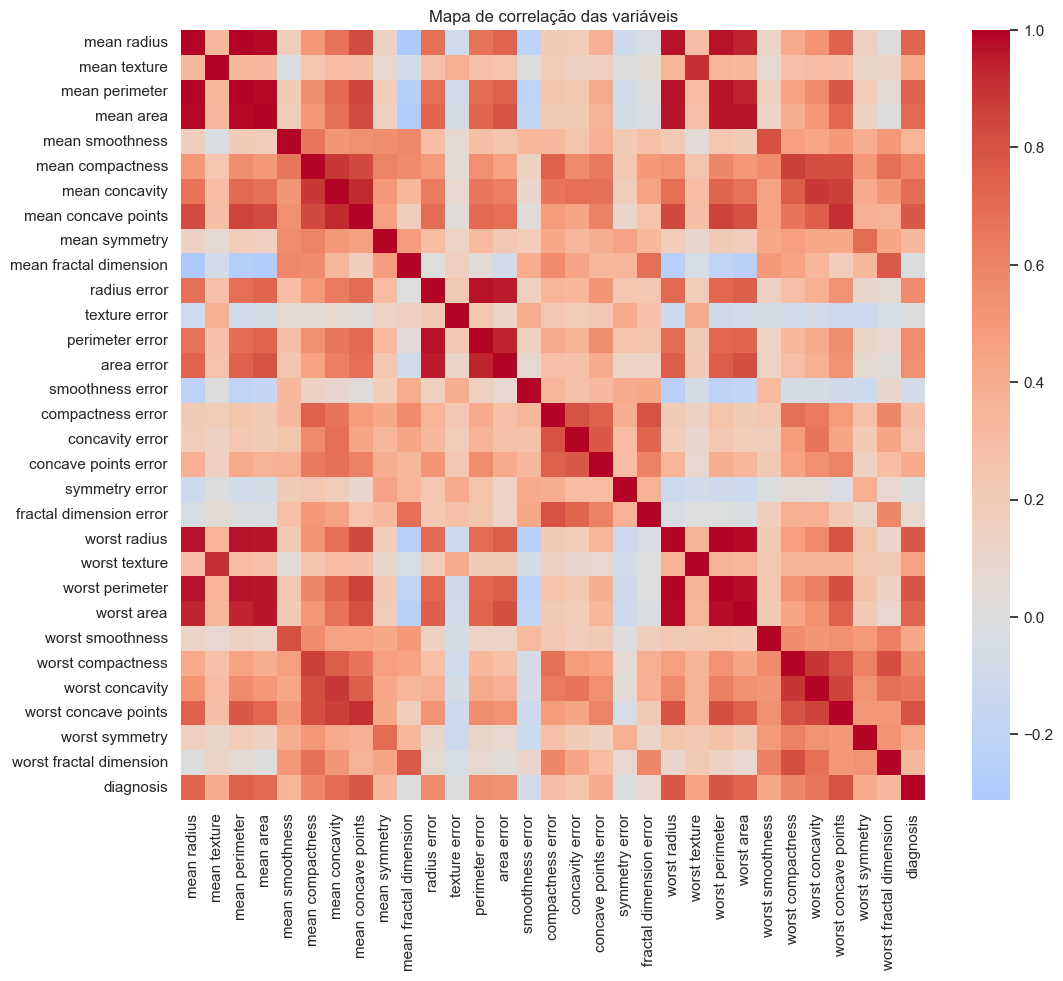

,Correlação absoluta com diagnóstico
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636
worst area,0.733825
mean radius,0.730029
mean area,0.708984
mean concavity,0.696360
worst concavity,0.659610


In [9]:
corr_df = df.drop(columns=["id", "Unnamed: 32"]).copy()
corr_df["diagnosis"] = corr_df["diagnosis"].map({"B": 0, "M": 1})

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0)
plt.title("Mapa de correlação das variáveis")
plt.show()

target_corr = corr_df.corr()["diagnosis"].drop("diagnosis").abs().sort_values(ascending=False).head(10)
target_corr.to_frame("Correlação absoluta com diagnóstico")


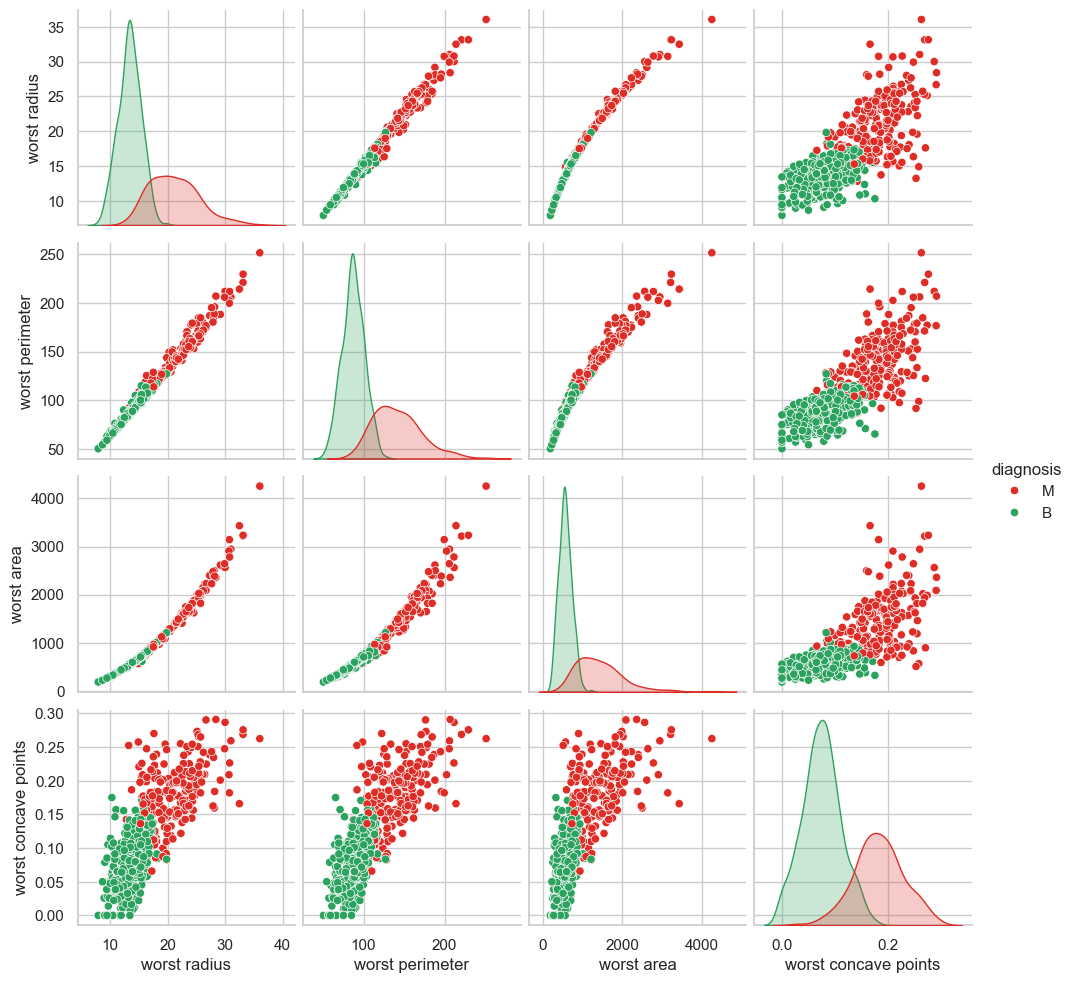

In [10]:
sns.pairplot(df[["worst radius", "worst perimeter", "worst area", "worst concave points", "diagnosis"]], hue="diagnosis", palette={"B": "#2ca25f", "M": "#de2d26"})
plt.show()


### Interpretação da EDA

A base tem mais casos benignos do que malignos, por isso a estratificação é importante na divisão dos dados. Variáveis como `worst concave points`, `worst perimeter`, `worst radius` e `worst area` mostram separação visual relevante entre as classes e forte correlação com o diagnóstico. Em contexto oncológico, reduzir falsos negativos é especialmente importante, pois um tumor maligno classificado como benigno pode atrasar investigação clínica.


## 4. Pré-processamento e divisão dos dados

Removemos identificadores sem valor preditivo, convertemos a classe para número e separamos os dados em treino, validação e teste. A divisão é estratificada para manter proporção parecida de benignos e malignos em cada conjunto.


In [11]:
df_model = df.drop(columns=["id", "Unnamed: 32"]).copy()
df_model["diagnosis"] = df_model["diagnosis"].map({"M": 1, "B": 0})

X = df_model.drop(columns="diagnosis")
y = df_model["diagnosis"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

split_table = pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste"],
    "Amostras": [len(y_train), len(y_val), len(y_test)],
    "% maligno": [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100],
}).round(2)
display(split_table)


,Conjunto,Amostras,% maligno
0,Treino,341,37.24
1,Validação,114,37.72
2,Teste,114,36.84


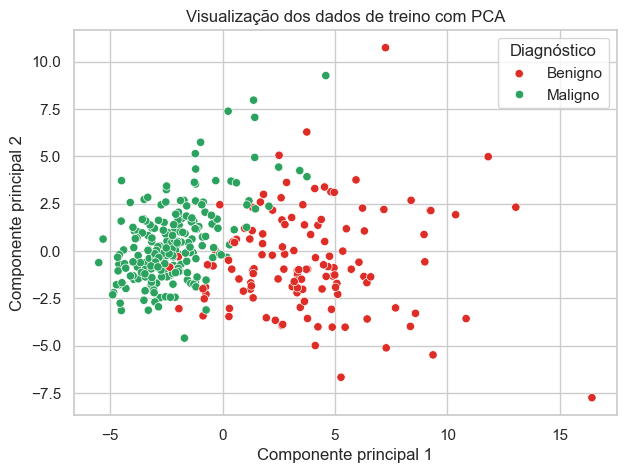

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_train_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette={0: "#2ca25f", 1: "#de2d26"})
plt.title("Visualização dos dados de treino com PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Diagnóstico", labels=["Benigno", "Maligno"])
plt.show()


## 5. Pipelines e modelos comparados

Cada modelo foi colocado em um `Pipeline` com `StandardScaler` e `SelectKBest`. Isso evita vazamento de dados, pois a padronização e a seleção de features são ajustadas apenas no treino durante validação cruzada.


In [13]:
models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=15)),
        ("classifier", SVC(probability=True, random_state=42)),
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=15)),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]),
    "NaiveBayes": Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=15)),
        ("classifier", GaussianNB()),
    ]),
}

def evaluate(model_name, split_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    return {
        "Modelo": model_name,
        "Conjunto": split_name,
        "Acurácia": accuracy_score(y_eval, y_pred),
        "Precisão": precision_score(y_eval, y_pred),
        "Recall": recall_score(y_eval, y_pred),
        "F1": f1_score(y_eval, y_pred),
        "AUC": roc_auc_score(y_eval, y_prob),
    }


In [14]:
initial_results = []
fitted_initial_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_initial_models[name] = model
    initial_results.append(evaluate(name, "Validação inicial", model, X_val, y_val))

initial_results_df = pd.DataFrame(initial_results)
display(initial_results_df.round(4).sort_values("F1", ascending=False))


,Modelo,Conjunto,Acurácia,Precisão,Recall,F1,AUC
1,RandomForest,Validação inicial,0.9737,0.9762,0.9535,0.9647,0.9921
0,SVM,Validação inicial,0.9649,0.9756,0.9302,0.9524,0.9921
2,NaiveBayes,Validação inicial,0.9386,0.9091,0.9302,0.9195,0.9823


## 6. Validação cruzada e otimização de hiperparâmetros

A otimização usa `GridSearchCV` com `StratifiedKFold`. Os hiperparâmetros são escolhidos pelo F1 na validação cruzada, equilibrando precisão e recall. Depois, os melhores modelos são avaliados no conjunto de validação e somente ao final no teste.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grids = {
    "SVM": (models["SVM"], {
        "selector__k": [10, 15, 20],
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": [0.001, 0.01, 0.1],
        "classifier__kernel": ["rbf"],
    }),
    "RandomForest": (models["RandomForest"], {
        "selector__k": [10, 15, 20],
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [5, 10, None],
        "classifier__min_samples_split": [2, 5],
    }),
}

best_models = {}
optimized_rows = []
for name, (pipeline, params) in grids.items():
    search = GridSearchCV(pipeline, params, scoring="f1", cv=cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"{name}: melhores parâmetros = {search.best_params_}")
    optimized_rows.append(evaluate(name, "Validação otimizada", search.best_estimator_, X_val, y_val))
    optimized_rows.append(evaluate(name, "Teste final", search.best_estimator_, X_test, y_test))

optimized_results_df = pd.DataFrame(optimized_rows)
display(optimized_results_df.round(4).sort_values(["Conjunto", "F1"], ascending=[True, False]))


SVM: melhores parâmetros = {'classifier__C': 10, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf', 'selector__k': 20}
RandomForest: melhores parâmetros = {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200, 'selector__k': 20}


,Modelo,Conjunto,Acurácia,Precisão,Recall,F1,AUC
1,SVM,Teste final,0.9825,0.9762,0.9762,0.9762,0.9960
3,RandomForest,Teste final,0.9649,1.0000,0.9048,0.9500,0.9974
2,RandomForest,Validação otimizada,0.9737,0.9762,0.9535,0.9647,0.9903
0,SVM,Validação otimizada,0.9649,0.9535,0.9535,0.9535,0.9957


In [16]:
comparative_table = pd.concat([initial_results_df, optimized_results_df], ignore_index=True)
comparative_table = comparative_table.sort_values(["Conjunto", "F1", "Recall"], ascending=[True, False, False])
display(comparative_table.round(4))
comparative_table.to_csv(REPORTS_PATH / "metricas_consolidadas_notebook.csv", index=False)


,Modelo,Conjunto,Acurácia,Precisão,Recall,F1,AUC
4,SVM,Teste final,0.9825,0.9762,0.9762,0.9762,0.9960
6,RandomForest,Teste final,0.9649,1.0000,0.9048,0.9500,0.9974
1,RandomForest,Validação inicial,0.9737,0.9762,0.9535,0.9647,0.9921
0,SVM,Validação inicial,0.9649,0.9756,0.9302,0.9524,0.9921
2,NaiveBayes,Validação inicial,0.9386,0.9091,0.9302,0.9195,0.9823
5,RandomForest,Validação otimizada,0.9737,0.9762,0.9535,0.9647,0.9903
3,SVM,Validação otimizada,0.9649,0.9535,0.9535,0.9535,0.9957


## 7. Gráficos finais de avaliação

A matriz de confusão mostra erros por tipo. Em oncologia, falsos negativos recebem atenção especial. A curva ROC e AUC avaliam a capacidade de separar benignos e malignos considerando diferentes limiares de decisão.


Modelo escolhido pela validação: RandomForest
              precision    recall  f1-score   support

     Benigno       0.95      1.00      0.97        72
     Maligno       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



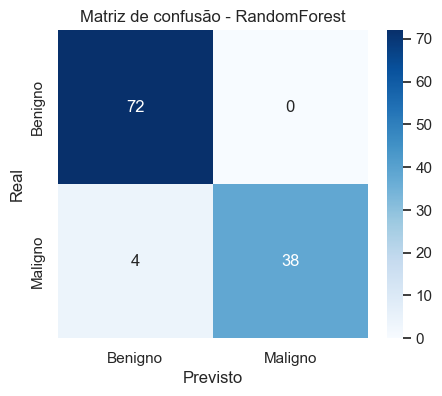

In [17]:
best_validation = optimized_results_df[optimized_results_df["Conjunto"] == "Validação otimizada"].sort_values(["F1", "Recall", "AUC"], ascending=False).iloc[0]
final_model_name = best_validation["Modelo"]
final_model = best_models[final_model_name]
print("Modelo escolhido pela validação:", final_model_name)

y_pred_test = final_model.predict(X_test)
y_prob_test = final_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_test, target_names=["Benigno", "Maligno"]))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benigno", "Maligno"], yticklabels=["Benigno", "Maligno"])
plt.title(f"Matriz de confusão - {final_model_name}")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()


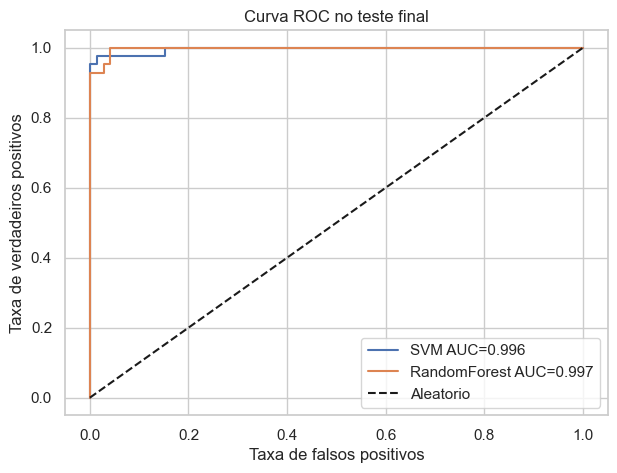

In [18]:
plt.figure(figsize=(7, 5))
for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Aleatorio")
plt.title("Curva ROC no teste final")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## 8. Seleção e importância das features

A seleção de features reduz o modelo para as variáveis mais informativas. No RandomForest final, a importância indica quais variáveis mais contribuíram para as divisões das árvores. Variáveis de tamanho, perímetro, área e pontos côncavos costumam ter interpretação biológica coerente, pois refletem irregularidade e extensão celular.


,Feature,Importance
13,worst perimeter,0.163509
11,worst radius,0.146740
14,worst area,0.118064
18,worst concave points,0.112525
6,mean concave points,0.112478
5,mean concavity,0.071859
0,mean radius,0.044013
3,mean area,0.041501
2,mean perimeter,0.036183
12,worst texture,0.025880


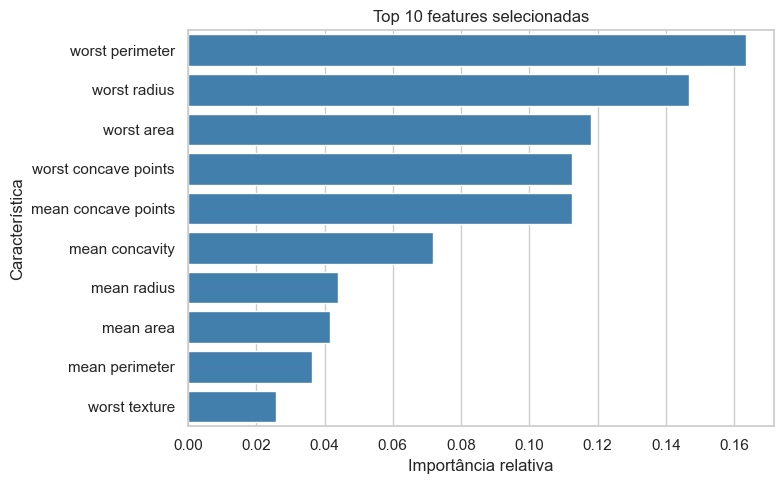

In [19]:
selected_mask = final_model.named_steps["selector"].get_support()
selected_features = X.columns[selected_mask]
classifier = final_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
else:
    scores = final_model.named_steps["selector"].scores_[selected_mask]
    importances = scores / scores.sum()

feature_importance_df = pd.DataFrame({"Feature": selected_features, "Importance": importances})
feature_importance_df = feature_importance_df.sort_values("Importance", ascending=False)
display(feature_importance_df.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df.head(10), x="Importance", y="Feature", color="#3182bd")
plt.title("Top 10 features selecionadas")
plt.xlabel("Importância relativa")
plt.ylabel("Característica")
plt.tight_layout()
plt.show()


## 9. Retreino e salvamento do modelo final

Depois da escolha pela validação, o modelo final é retreinado com treino + validação e salvo em `model/modelo_final.joblib`. O teste permanece separado para estimar desempenho final em dados não vistos.


In [20]:
final_model.fit(X_train_val, y_train_val)
joblib.dump(final_model, MODEL_PATH)
joblib.dump(list(X.columns), FEATURES_PATH)
print("Modelo salvo em:", MODEL_PATH)
print("Features salvas em:", FEATURES_PATH)

y_final_pred = final_model.predict(X_test)
y_final_prob = final_model.predict_proba(X_test)[:, 1]
final_metrics = pd.DataFrame([evaluate(final_model_name, "Teste final após retreino", final_model, X_test, y_test)])
display(final_metrics.round(4))


Modelo salvo em: c:\FACULDADE\ML\P2\model\modelo_final.joblib
Features salvas em: c:\FACULDADE\ML\P2\model\feature_names.joblib


,Modelo,Conjunto,Acurácia,Precisão,Recall,F1,AUC
0,RandomForest,Teste final após retreino,0.9561,1.0,0.881,0.9367,0.9936


## 10. Conclusão

A versão final corrige o principal ponto metodológico da P1 ao separar treino, validação e teste. A tabela consolidada facilita a comparação dos modelos, a seleção de features fortalece a análise e o pipeline salvo garante coerência entre notebook e app Streamlit.

O modelo apresenta alto desempenho geral, mas deve ser entendido como ferramenta educacional de apoio à decisão. Em aplicação real, uma predição maligna ou benigna nunca substitui avaliação médica, exames complementares e validação clínica.
